### Deep learning Raport Zaliczeniowy - Michał Dyło i Agnieszka Wardak

**Uwaga techniczna:** ta kopia notebooka używa lokalnego środowiska `Project.toml` oraz ścieżki względnej `data/raw/kaggle_room_street_data/house_data`, dzięki czemu nie zależy od absolutnych ścieżek Windows z komputera autora.


### Pobieranie i analiza eksporacyjna danych

In [2]:
using Images
using FileIO
using Plots
using StatsBase 
using Glob  
using Flux
using OneHotArrays      
using Random 

In [3]:
using Flux: DataLoader, logitcrossentropy, onecold

In [4]:
gr()


Plots.GRBackend()

In [ ]:
# Przenośna ścieżka do folderu z obrazami
# Zakładamy, że notebook jest uruchamiany z katalogu projektu lub jego podkatalogu.
function find_project_root(start_dir=pwd())
    current = abspath(start_dir)
    while true
        data_candidate = joinpath(current, "data", "raw", "kaggle_room_street_data", "house_data")
        if isdir(data_candidate)
            return current
        end
        parent = dirname(current)
        parent == current && error("Nie znaleziono data/raw/kaggle_room_street_data/house_data. Uruchom scripts/download_dataset.sh albo rozpakuj dataset Kaggle do data/raw.")
        current = parent
    end
end

const PROJECT_ROOT = find_project_root()
const DATA_DIR = joinpath(PROJECT_ROOT, "data", "raw", "kaggle_room_street_data", "house_data")

# Funkcja pomocnicza: sprawdza, czy folder istnieje
if !isdir(DATA_DIR)
    println("BŁĄD: Nie znaleziono folderu $DATA_DIR.")
else
    println("Zlokalizowano folder z danymi: $DATA_DIR")
end


In [ ]:
# Pobranie listy wszystkich plików .jpg z folderu
all_files = readdir(DATA_DIR)
filter!(f -> endswith(lowercase(f), ".jpg"), all_files)

println("Łączna liczba obrazów .jpg w folderze: ", length(all_files))

# Funkcja do wyciągania nazwy klasy z nazwy pliku 
function get_class_from_filename(filename::String)
    
    parts = split(filename, "_")
    return parts[1] 
end


filepaths = [joinpath(DATA_DIR, f) for f in all_files]
labels = [get_class_from_filename(f) for f in all_files]

# Sprawdzenie pierwszych 5 wyników
println("\nPrzykładowe dane:")
for i in 1:5
    println("Plik: $(filepaths[i]) --> Klasa: $(labels[i])")
end


Analiza klas obrazów


Liczebność poszczególnych klas:
- living : 1273 obrazów
- bath : 605 obrazów
- bed : 1248 obrazów
- kitchen : 965 obrazów
- din : 1158 obrazów


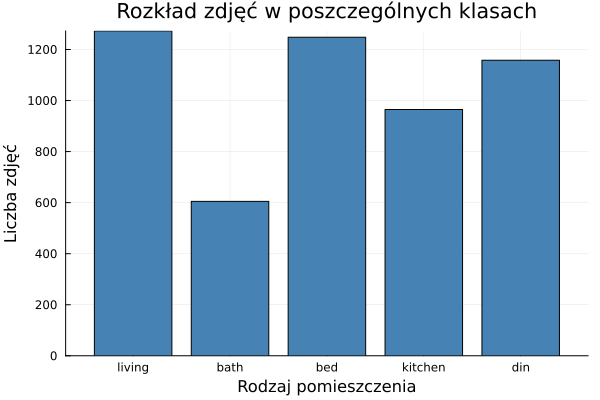

In [7]:
class_counts = countmap(labels)

println("\nLiczebność poszczególnych klas:")
for (klasa, count) in class_counts
    println("- $klasa : $count obrazów")
end

# Wykres słupkowych dostępnych klas
bar(
    collect(keys(class_counts)), 
    collect(values(class_counts)), 
    title="Rozkład zdjęć w poszczególnych klasach", 
    xlabel="Rodzaj pomieszczenia", 
    ylabel="Liczba zdjęć",
    legend=false,
    color=:steelblue
)

In [8]:
#Sprawdzenie rozdzieloczosci obrazow

widths = Int[]
heights = Int[]


for path in filepaths
    try
        # Wczytujemy obraz. Wymiary to (Wysokość x Szerokość) 
        img = load(path)
        h, w = size(img)
        push!(heights, h)
        push!(widths, w)
    catch e
        println("Ostrzeżenie: Nie udało się wczytać pliku $path")
    end
end

println("Maksymalna szerokość: ", maximum(widths), " px")
println("Minimalna szerokość:  ", minimum(widths), " px")
println("Średnia szerokość:    ", round(mean(widths), digits=1), " px")

println("\nMaksymalna wysokość:  ", maximum(heights), " px")
println("Minimalna wysokość:   ", minimum(heights), " px")
println("Średnia wysokość:     ", round(mean(heights), digits=1), " px")



Maksymalna szerokość: 224 px
Minimalna szerokość:  224 px
Średnia szerokość:    224.0 px

Maksymalna wysokość:  224 px
Minimalna wysokość:   224 px
Średnia wysokość:     224.0 px


Wyświetlenie kilku przykładowych obrazów.


Przykładowe obrazy:
Klasa: LIVING


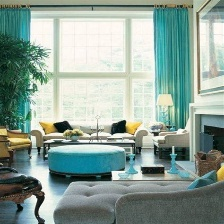

Klasa: BATH


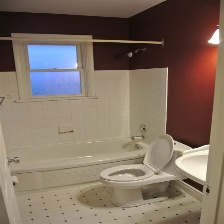

Klasa: BED


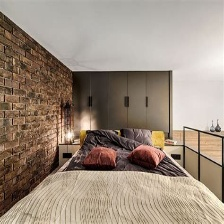

Klasa: KITCHEN


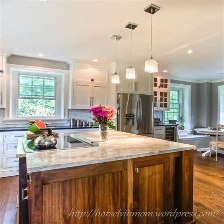

Klasa: DIN


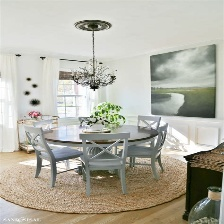

In [9]:
unique_classes = collect(keys(class_counts))
sample_images = []

for cls in unique_classes
    
    indices = findall(x -> x == cls, labels)
    
    random_idx = rand(indices)
    
    img = load(filepaths[random_idx])
    push!(sample_images, (cls, img))
end

# Funkcja pomocnicza z pakietu Plots/Images do pokazania siatki zdjęć


println("\nPrzykładowe obrazy:")
for (cls, img) in sample_images
    println("Klasa: ", uppercase(cls))
    
    display(img) 
end


### Data preprocessing - odrzucenie klasy bath (za mało obiektów), kodowanie klas, resizing (na 64x64)

In [10]:
# Odrzucenie kalsy bath
valid_indices = findall(x -> x != "bath", labels)
filtered_filepaths = filepaths[valid_indices]
filtered_labels = labels[valid_indices]

println("Liczba obrazów po usunięciu klasy 'bath': ", length(filtered_filepaths))

# słownik do zamiany nazw klas (string) na indeksy
unique_labels = unique(filtered_labels)
label_to_id = Dict(label => i for (i, label) in enumerate(unique_labels))
println("Utworzone mapowanie klas: ", label_to_id)

Liczba obrazów po usunięciu klasy 'bath': 4644
Utworzone mapowanie klas: Dict{SubString{String}, Int64}("living" => 4, "bed" => 1, "kitchen" => 3, "din" => 2)


In [12]:
# Transformacja obrazow na tensory
const IMG_SIZE = (64, 64) 

function process_image(path)
    img = load(path)
    # Zmniejszanie obrazu
    img_resized = imresize(img, IMG_SIZE)
    
    
    arr = Float32.(channelview(img_resized))
    
    # Zabezpieczenie przed obrazami w skali szarości 
    if ndims(arr) == 2 || size(arr, 1) != 3
        return nothing 
    end
    
    # Format Flux
   
    return permutedims(arr, (3, 2, 1))
end


temp_X_data = Array{Float32, 3}[]
y_data = Int[]

for (i, path) in enumerate(filtered_filepaths)
    tensor = process_image(path)
    if tensor !== nothing
        push!(temp_X_data, tensor)
        push!(y_data, label_to_id[filtered_labels[i]])
    end
end


num_valid_images = length(temp_X_data)
X = Array{Float32, 4}(undef, IMG_SIZE[1], IMG_SIZE[2], 3, num_valid_images)

for i in 1:num_valid_images
    X[:, :, :, i] .= temp_X_data[i]
end

# Czyszczenie pamieci
temp_X_data = nothing

# Zmieniamy etykiety liczbowe na reprezentację One-Hot 
Y = onehotbatch(y_data, 1:length(unique_labels))

println("\nFormat wejścia (X) gotowy dla sieci: ", size(X))
println("Format wyjścia (Y) gotowy dla sieci: ", size(Y))


Format wejścia (X) gotowy dla sieci: (64, 64, 3, 4644)
Format wyjścia (Y) gotowy dla sieci: (4, 4644)


In [13]:
# Podzial na klasy (70% zbior treningowy, 15% walidacyjny, 15% testowy)
N = size(X, 4) 
Random.seed!(42)
shuffled_indices = randperm(N)

# 70% na trening, 15% na walidację, 15% na ostateczny test
train_end = floor(Int, 0.70 * N)
val_end = floor(Int, 0.85 * N)

idx_train = shuffled_indices[1:train_end]
idx_val = shuffled_indices[train_end+1:val_end]
idx_test = shuffled_indices[val_end+1:end]

X_train, Y_train = X[:, :, :, idx_train], Y[:, idx_train]
X_val,   Y_val   = X[:, :, :, idx_val],   Y[:, idx_val]
X_test,  Y_test  = X[:, :, :, idx_test],  Y[:, idx_test]

println("\n--- Podsumowanie Danych do Treningu ---")
println("Rozmiar X_train: ", size(X_train))
println("Rozmiar X_val:   ", size(X_val))
println("Rozmiar X_test:  ", size(X_test))


--- Podsumowanie Danych do Treningu ---
Rozmiar X_train: (64, 64, 3, 3250)
Rozmiar X_val:   (64, 64, 3, 697)
Rozmiar X_test:  (64, 64, 3, 697)


### Pierwsza sieć - klasyczna gęsta sieć neuronowa

In [14]:
# Rozmiar pojedynczego obrazu po "spłaszczeniu" (64 * 64 * 3 = 12288)
INPUT_DIM = IMG_SIZE[1] * IMG_SIZE[2] * 3
NUM_CLASSES = length(unique_labels)

# Funkcja budująca model na podstawie zadanego ID topologii i wskaźnika dropout
function build_mlp_model(topology_id, p_dropout)
    if topology_id == 1
        return Chain(
            Flux.flatten, 
            Dense(INPUT_DIM => 512, relu), 
            Dropout(p_dropout), 
            Dense(512 => NUM_CLASSES)
        )
    elseif topology_id == 2
        return Chain(
            Flux.flatten, 
            Dense(INPUT_DIM => 256, relu), 
            Dropout(p_dropout), 
            Dense(256 => 64, relu), 
            Dropout(p_dropout), 
            Dense(64 => NUM_CLASSES)
        )
    elseif topology_id == 3
        return Chain(
            Flux.flatten, 
            Dense(INPUT_DIM => 128, relu), 
            Dropout(p_dropout), 
            Dense(128 => 64, relu), 
            Dense(64 => 32, relu), 
            Dense(32 => NUM_CLASSES)
        )
    end
end

build_mlp_model (generic function with 1 method)

In [15]:
# Siatka hiperparametrow
batch_sizes    = [32, 64]
learning_rates = [0.001, 0.0005, 0.0001]
dropout_rates  = [0.3] 
topologies     = [1, 2, 3]


3-element Vector{Int64}:
 1
 2
 3

In [16]:
# Funkcja pomocnicza do bezpiecznego oceniania strat/dokładności na wsadach

function evaluate_model(model, loader)
    # UWAGA: Włączamy testmode! To dezaktywuje Dropout.
    Flux.testmode!(model, true)
    
    total_loss = 0.0f0
    correct = 0
    total = 0
    
    for (x, y) in loader
        y_hat = model(x)
        total_loss += logitcrossentropy(y_hat, y) * size(x, 4)
        correct += sum(onecold(y_hat) .== onecold(y))
        total += size(x, 4)
    end
    
    Flux.testmode!(model, false) # Powrót do trybu uczenia
    return total_loss / total, correct / total
end

evaluate_model (generic function with 1 method)

In [17]:
epochs = 10 

10

In [18]:
println("\nRozpoczęcie przeszukiwania siatki hiperparametrów (Grid Search)...")

# Zmienne globalne do przechowywania najlepszego modelu 
global best_val_acc = 0.0
global best_params = nothing
global best_model = nothing
global best_history = nothing

# Iteracja po kombinacjach hiperparametrow
for bs in batch_sizes, lr in learning_rates, p in dropout_rates, topo in topologies
    
    println("\nTrenowanie -> Topologia: $topo, Batch: $bs, LR: $lr, Dropout: $p")
    
    model = build_mlp_model(topo, p)
    
    
    opt_state = Flux.setup(Adam(lr), model)
        
    train_loader = DataLoader((X_train, Y_train), batchsize=bs, shuffle=true)
    val_loader   = DataLoader((X_val, Y_val), batchsize=bs, shuffle=false)
    
    hist_train_loss, hist_val_loss = Float64[], Float64[]
    hist_train_acc, hist_val_acc   = Float64[], Float64[]
    
    # Pętla treningowa
    for ep in 1:epochs
    
        Flux.train!(model, train_loader, opt_state) do m, x, y
            logitcrossentropy(m(x), y)
        end
        
        t_loss, t_acc = evaluate_model(model, train_loader)
        v_loss, v_acc = evaluate_model(model, val_loader)
        
        push!(hist_train_loss, t_loss)
        push!(hist_val_loss, v_loss)
        push!(hist_train_acc, t_acc)
        push!(hist_val_acc, v_acc)
    end
    
    v_acc_final = hist_val_acc[end]
    println("Koniec treningu. Val Acc: ", round(v_acc_final * 100, digits=2), "%")
    
    # Zapisz, jeśli to najlepszy model
    if v_acc_final > best_val_acc
        global best_val_acc = v_acc_final
        global best_params = (bs, lr, p, topo)
        global best_model = deepcopy(model) 
        global best_history = (hist_train_loss, hist_val_loss, hist_train_acc, hist_val_acc)
    end
end

println("\n" * "="^50)
println("ZAKOŃCZONO GRID SEARCH.")
println("Najlepsze Accuracy Walidacyjne: ", round(best_val_acc * 100, digits=2), "%")
println("Zwycięskie parametry:")
println("- Rozmiar paczki (Batch Size): ", best_params[1])
println("- Współczynnik uczenia (LR)  : ", best_params[2])
println("- Dropout Rate               : ", best_params[3])
println("- Topologia                  : ", best_params[4])
println("="^50)



Rozpoczęcie przeszukiwania siatki hiperparametrów (Grid Search)...

Trenowanie -> Topologia: 1, Batch: 32, LR: 0.001, Dropout: 0.3
Koniec treningu. Val Acc: 29.7%

Trenowanie -> Topologia: 2, Batch: 32, LR: 0.001, Dropout: 0.3
Koniec treningu. Val Acc: 28.41%

Trenowanie -> Topologia: 3, Batch: 32, LR: 0.001, Dropout: 0.3
Koniec treningu. Val Acc: 28.41%

Trenowanie -> Topologia: 1, Batch: 32, LR: 0.0005, Dropout: 0.3
Koniec treningu. Val Acc: 38.16%

Trenowanie -> Topologia: 2, Batch: 32, LR: 0.0005, Dropout: 0.3
Koniec treningu. Val Acc: 28.41%

Trenowanie -> Topologia: 3, Batch: 32, LR: 0.0005, Dropout: 0.3
Koniec treningu. Val Acc: 28.41%

Trenowanie -> Topologia: 1, Batch: 32, LR: 0.0001, Dropout: 0.3
Koniec treningu. Val Acc: 39.45%

Trenowanie -> Topologia: 2, Batch: 32, LR: 0.0001, Dropout: 0.3
Koniec treningu. Val Acc: 33.72%

Trenowanie -> Topologia: 3, Batch: 32, LR: 0.0001, Dropout: 0.3
Koniec treningu. Val Acc: 33.43%

Trenowanie -> Topologia: 1, Batch: 64, LR: 0.001, Dro

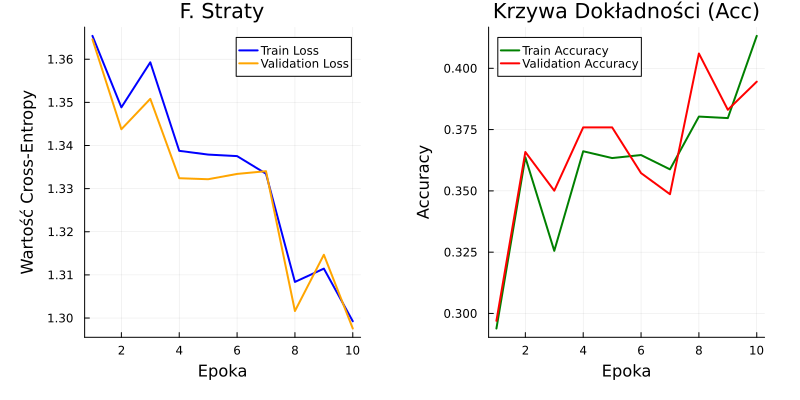

In [20]:
# Najlepszy model - funkcja straty
h_t_loss, h_v_loss, h_t_acc, h_v_acc = best_history

# Wykres 1: Funkcja Straty (Loss)
p1 = plot(1:epochs, h_t_loss, label="Train Loss", lw=2, color=:blue, title="F. Straty")
plot!(p1, 1:epochs, h_v_loss, label="Validation Loss", lw=2, color=:orange)
xlabel!(p1, "Epoka")
ylabel!(p1, "Wartość Cross-Entropy")

# Wykres 2: Dokładność (Accuracy)
p2 = plot(1:epochs, h_t_acc, label="Train Accuracy", lw=2, color=:green, title="Krzywa Dokładności (Acc)")
plot!(p2, 1:epochs, h_v_acc, label="Validation Accuracy", lw=2, color=:red)
xlabel!(p2, "Epoka")
ylabel!(p2, "Accuracy")

display(plot(p1, p2, layout=(1, 2), size=(800, 400), bottom_margin=7Plots.Measures.mm, left_margin=7Plots.Measures.mm, right_margin=7Plots.Measures.mm))


Ewaluacja na zbiorze testowym

In [21]:
test_loader = DataLoader((X_test, Y_test), batchsize=best_params[1], shuffle=false)
test_loss, test_acc = evaluate_model(best_model, test_loader)

println("Ogólne Accuracy na Zbiorze Testowym: ", round(test_acc * 100, digits=2), "%\n")

Ogólne Accuracy na Zbiorze Testowym: 39.6%



In [22]:
Flux.testmode!(best_model, true)
# Pobieramy predykcje 
Y_test_pred_logits = best_model(X_test)
Y_test_pred_indices = onecold(Y_test_pred_logits)
Y_test_true_indices = onecold(Y_test)
Flux.testmode!(best_model, false)

#Macierz pomylek (ktora uwzglednia wszystkie klasy)
C = zeros(Int, NUM_CLASSES, NUM_CLASSES)

for (p, t) in zip(Y_test_pred_indices, Y_test_true_indices)
    C[p, t] += 1
end

# Wizualizacja Tekstowa Macierzy Pomyłek
println("MACIERZ POMYŁEK:")
println("Kolumny - prawdziwe klasy")
println("Wiersze - predykcja \n")

header = "PREDYKCJA \\ PRAWD. | " * join([rpad(string(cls), 10) for cls in unique_labels], " | ")
println(header)
println("-" ^ length(header))

for p in 1:NUM_CLASSES
    row_str = rpad(string(unique_labels[p]), 19) * "| "
    for t in 1:NUM_CLASSES
        row_str *= rpad(string(C[p, t]), 10) * " | "
    end
    println(row_str)
end

MACIERZ POMYŁEK:
Kolumny - prawdziwe klasy
Wiersze - predykcja 

PREDYKCJA \ PRAWD. | bed        | din        | kitchen    | living    
----------------------------------------------------------------------
bed                | 98         | 60         | 30         | 52         | 
din                | 48         | 96         | 51         | 42         | 
kitchen            | 6          | 11         | 24         | 19         | 
living             | 35         | 32         | 35         | 58         | 


In [23]:
total_samples = sum(C)
# Obliczanie Precision i Recall dla każdej klasy
for i in 1:NUM_CLASSES

    TP = C[i, i]
        
    total_predicted_as_i = sum(C[i, :])
    
    total_true_i = sum(C[:, i])
        
    TN = total_samples - total_predicted_as_i - total_true_i + TP
    
    precision = total_predicted_as_i > 0 ? TP / total_predicted_as_i : 0.0
    recall    = total_true_i > 0 ? TP / total_true_i : 0.0
        
    println("Klasa: ", rpad(uppercase(string(unique_labels[i])), 10), 
             "Precision: ", rpad(round(precision * 100, digits=2), 5), 
            "% | Recall: ", rpad(round(recall * 100, digits=2), 5), "%")
end


Klasa: BED       Precision: 40.83% | Recall: 52.41%
Klasa: DIN       Precision: 40.51% | Recall: 48.24%
Klasa: KITCHEN   Precision: 40.0 % | Recall: 17.14%
Klasa: LIVING    Precision: 36.25% | Recall: 33.92%


Trening najlepszego modelu na 30 epokach

In [24]:
final_topo = 1
final_bs   = 32
final_lr   = 0.0001
final_p    = 0.3

# 30 epok
max_epochs = 30
patience   = 3

final_model = build_mlp_model(final_topo, final_p)
opt_state_final = Flux.setup(Adam(final_lr), final_model)

train_loader_final = DataLoader((X_train, Y_train), batchsize=final_bs, shuffle=true)
val_loader_final   = DataLoader((X_val, Y_val), batchsize=final_bs, shuffle=false)
test_loader_final  = DataLoader((X_test, Y_test), batchsize=final_bs, shuffle=false)

hist_t_loss_es, hist_v_loss_es = Float64[], Float64[]
hist_t_acc_es, hist_v_acc_es   = Float64[], Float64[]

global best_val_acc_es = 0.0
global patience_counter = 0
global best_es_model = nothing

for ep in 1:max_epochs
    Flux.train!(final_model, train_loader_final, opt_state_final) do m, x, y
        logitcrossentropy(m(x), y)
    end
    
    t_loss, t_acc = evaluate_model(final_model, train_loader_final)
    v_loss, v_acc = evaluate_model(final_model, val_loader_final)
    
    push!(hist_t_loss_es, t_loss)
    push!(hist_v_loss_es, v_loss)
    push!(hist_t_acc_es, t_acc)
    push!(hist_v_acc_es, v_acc)
    
    print("Epoka ", rpad(ep, 2), ": Train Acc: ", rpad(round(t_acc*100, digits=2), 5), "% | ")
    print("Val Acc: ", rpad(round(v_acc*100, digits=2), 5), "%")
    
    # Early Stopping
    if v_acc > best_val_acc_es
        global best_val_acc_es = v_acc
        global patience_counter = 0
        global best_es_model = deepcopy(final_model)
        println("  -> Nowy rekord! Zapisano model.")
    else
        global patience_counter += 1
        println("  -> Brak poprawy (Od: $patience_counter epok).")
    end
    flush(stdout)
    
    if patience_counter >= patience
        println("\n[EARLY STOPPING] Przerwano trening po $ep epokach. Model zaczął ulegać przeuczeniu lub przestał się poprawiać.")
        break
    end
end

Epoka 1 : Train Acc: 33.11% | Val Acc: 34.58%  -> Nowy rekord! Zapisano model.
Epoka 2 : Train Acc: 35.66% | Val Acc: 37.88%  -> Nowy rekord! Zapisano model.
Epoka 3 : Train Acc: 38.74% | Val Acc: 37.88%  -> Brak poprawy (Od: 1 epok).
Epoka 4 : Train Acc: 36.09% | Val Acc: 36.15%  -> Brak poprawy (Od: 2 epok).
Epoka 5 : Train Acc: 36.83% | Val Acc: 37.16%  -> Brak poprawy (Od: 3 epok).

[EARLY STOPPING] Przerwano trening po 5 epokach. Model zaczął ulegać przeuczeniu lub przestał się poprawiać.


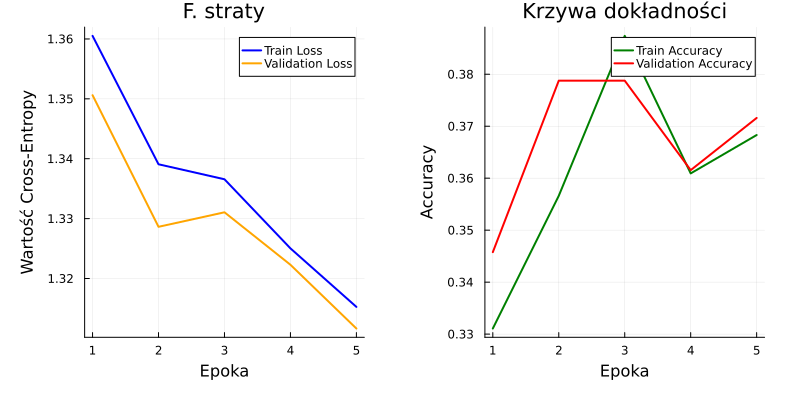

In [29]:
actual_epochs = length(hist_t_loss_es)

p3 = plot(1:actual_epochs, hist_t_loss_es, label="Train Loss", lw=2, color=:blue, title="F. straty")
plot!(p3, 1:actual_epochs, hist_v_loss_es, label="Validation Loss", lw=2, color=:orange)
xlabel!(p3, "Epoka")
ylabel!(p3, "Wartość Cross-Entropy")

p4 = plot(1:actual_epochs, hist_t_acc_es, label="Train Accuracy", lw=2, color=:green, title="Krzywa dokładności")
plot!(p4, 1:actual_epochs, hist_v_acc_es, label="Validation Accuracy", lw=2, color=:red)
xlabel!(p4, "Epoka")
ylabel!(p4, "Accuracy")

display(plot(p3, p4, layout=(1, 2), size=(800, 400), bottom_margin=7Plots.Measures.mm, left_margin=7Plots.Measures.mm, right_margin=7Plots.Measures.mm))

In [26]:
_, final_train_acc = evaluate_model(best_es_model, train_loader_final)
_, final_test_acc = evaluate_model(best_es_model, test_loader_final)

println("Ogólne Accuracy na Zbiorze Treningowym: ", round(final_train_acc * 100, digits=2), "%")
println("Ogólne Accuracy na Zbiorze Testowym: ", round(final_test_acc * 100, digits=2), "%\n")

Flux.testmode!(best_es_model, true) 
Y_test_pred_logits_es = best_es_model(X_test)
Y_test_pred_indices_es = onecold(Y_test_pred_logits_es)

Y_test_true_indices = onecold(Y_test)
Flux.testmode!(best_es_model, false)

C_es = zeros(Int, NUM_CLASSES, NUM_CLASSES)
for (p, t) in zip(Y_test_pred_indices_es, Y_test_true_indices)
    C_es[p, t] += 1
end

Ogólne Accuracy na Zbiorze Treningowym: 35.66%
Ogólne Accuracy na Zbiorze Testowym: 35.44%



In [27]:
header = "PREDYKCJA \\ PRAWD. | " * join([rpad(string(cls), 10) for cls in unique_labels], " | ")
println(header)
println("-" ^ length(header))

for p in 1:NUM_CLASSES
    row_str = rpad(string(unique_labels[p]), 19) * "| "
    for t in 1:NUM_CLASSES
        row_str *= rpad(string(C_es[p, t]), 10) * " | "
    end
    println(row_str)
end

PREDYKCJA \ PRAWD. | bed        | din        | kitchen    | living    
----------------------------------------------------------------------
bed                | 99         | 67         | 40         | 70         | 
din                | 66         | 116        | 78         | 70         | 
kitchen            | 3          | 4          | 8          | 7          | 
living             | 19         | 12         | 14         | 24         | 


In [30]:
total_samples_es = sum(C_es)

for i in 1:NUM_CLASSES
    TP = C_es[i, i]
    total_predicted_as_i = sum(C_es[i, :])
    total_true_i = sum(C_es[:, i])
    TN = total_samples_es - total_predicted_as_i - total_true_i + TP
    
    precision = total_predicted_as_i > 0 ? TP / total_predicted_as_i : 0.0
    recall    = total_true_i > 0 ? TP / total_true_i : 0.0
       
    println("Klasa: ", rpad(uppercase(string(unique_labels[i])), 10), 
            "Precision: ", rpad(round(precision * 100, digits=2), 5), 
            "% | Recall: ", rpad(round(recall * 100, digits=2), 5), "%")
end

Klasa: BED       Precision: 35.87% | Recall: 52.94%
Klasa: DIN       Precision: 35.15% | Recall: 58.29%
Klasa: KITCHEN   Precision: 36.36% | Recall: 5.71 %
Klasa: LIVING    Precision: 34.78% | Recall: 14.04%


### Model 2 - sieć konwolucyjna

In [25]:
NUM_CLASSES = length(unique_labels)
function evaluate_cnn(model, loader)
    Flux.testmode!(model, true)
    total_loss = 0.0f0
    correct = 0
    total = 0
    for (x, y) in loader
        y_hat = model(x)
        total_loss += logitcrossentropy(y_hat, y) * size(x, 4)
        correct += sum(onecold(y_hat) .== onecold(y))
        total += size(x, 4)
    end
    Flux.testmode!(model, false)
    return total_loss / total, correct / total
end

evaluate_cnn (generic function with 1 method)

In [ ]:
function build_cnn_model(topology_id, p_dropout)
        
    if topology_id == 1
        # Klasyczna CNN
        # 64 -> MaxPool -> 32 -> MaxPool -> 16 -> MaxPool -> 8
        return Chain(
            Conv((3, 3), 3 => 16, relu, pad=1),
            MaxPool((2, 2)),
            Conv((3, 3), 16 => 32, relu, pad=1),
            MaxPool((2, 2)),
            Conv((3, 3), 32 => 64, relu, pad=1),
            MaxPool((2, 2)),
            Flux.flatten,
            Dense(8 * 8 * 64 => 128, relu),
            Dropout(p_dropout),
            Dense(128 => NUM_CLASSES)
        )
    elseif topology_id == 2
        # VGG-lite
        # 64 -> MaxPool -> 32 -> MaxPool -> 16
        return Chain(
            Conv((3, 3), 3 => 16, relu, pad=1),
            Conv((3, 3), 16 => 16, relu, pad=1),
            MaxPool((2, 2)),
            Conv((3, 3), 16 => 32, relu, pad=1),
            Conv((3, 3), 32 => 32, relu, pad=1),
            MaxPool((2, 2)),
            Flux.flatten,
            Dense(16 * 16 * 32 => 256, relu),
            Dropout(p_dropout),
            Dense(256 => NUM_CLASSES)
        )
    elseif topology_id == 3
        # Agresywna, duży filtr na start
        # Filtr 5x5 przy pad=2 również zachowuje wymiary
        return Chain(
            Conv((5, 5), 3 => 16, relu, pad=2),
            MaxPool((2, 2)),
            Conv((3, 3), 16 => 32, relu, pad=1),
            MaxPool((2, 2)),
            Flux.flatten,
            Dense(16 * 16 * 32 => 64, relu),
            Dropout(p_dropout),
            Dense(64 => NUM_CLASSES)
        )
    end
end

build_cnn_model (generic function with 1 method)

In [27]:
# Siatka hiperparametrow
cnn_batch_sizes    = [32, 64]
cnn_learning_rates = [0.001, 0.0005]
cnn_dropout_rates  = [0.3, 0.5] 
cnn_topologies     = [1, 2, 3]

3-element Vector{Int64}:
 1
 2
 3

In [28]:
epochs_cnn = 5 

5

In [29]:
println("\nRozpoczęcie przeszukiwania siatki hiperparametrów CNN (Grid Search)...")
flush(stdout)

global best_cnn_val_acc = 0.0
global best_cnn_params = nothing
global best_cnn_model = nothing
global best_cnn_history = nothing

for bs in cnn_batch_sizes, lr in cnn_learning_rates, p in cnn_dropout_rates, topo in cnn_topologies
    
    println("\nTrenowanie CNN -> Topologia: $topo, Batch: $bs, LR: $lr, Dropout: $p")
    flush(stdout)
    
    model = build_cnn_model(topo, p)
    opt_state = Flux.setup(Adam(lr), model)
    
    train_loader = DataLoader((X_train, Y_train), batchsize=bs, shuffle=true)
    val_loader   = DataLoader((X_val, Y_val), batchsize=bs, shuffle=false)
    
    hist_train_loss, hist_val_loss = Float64[], Float64[]
    hist_train_acc, hist_val_acc   = Float64[], Float64[]
    
    @time for ep in 1:epochs_cnn
        Flux.train!(model, train_loader, opt_state) do m, x, y
            logitcrossentropy(m(x), y)
        end
        
        t_loss, t_acc = evaluate_cnn(model, train_loader)
        v_loss, v_acc = evaluate_cnn(model, val_loader)
        
        push!(hist_train_loss, t_loss)
        push!(hist_val_loss, v_loss)
        push!(hist_train_acc, t_acc)
        push!(hist_val_acc, v_acc)
    end
    
    # Wymuszenie czyszczenia pamięci RAM z nieużywanych tensorów
    GC.gc() 
    
    v_acc_final = hist_val_acc[end]
    println("Koniec treningu CNN. Val Acc: ", round(v_acc_final * 100, digits=2), "%")
    flush(stdout)
    
    if v_acc_final > best_cnn_val_acc
        global best_cnn_val_acc = v_acc_final
        global best_cnn_params = (bs, lr, p, topo)
        global best_cnn_model = deepcopy(model) 
        global best_cnn_history = (hist_train_loss, hist_val_loss, hist_train_acc, hist_val_acc)
    end
end

println("\n" * "="^50)
println("ZAKOŃCZONO GRID SEARCH DLA CNN.")
println("Najlepsze Accuracy Walidacyjne: ", round(best_cnn_val_acc * 100, digits=2), "%")
println("Zwycięskie parametry CNN:")
println("- Rozmiar paczki (Batch Size): ", best_cnn_params[1])
println("- Współczynnik uczenia (LR)  : ", best_cnn_params[2])
println("- Dropout Rate               : ", best_cnn_params[3])
println("- Topologia                  : ", best_cnn_params[4])
println("="^50)
flush(stdout)



Rozpoczęcie przeszukiwania siatki hiperparametrów CNN (Grid Search)...

Trenowanie CNN -> Topologia: 1, Batch: 32, LR: 0.001, Dropout: 0.3
228.241356 seconds (19.71 M allocations: 41.090 GiB, 8.49% gc time, 8.75% compilation time)
Koniec treningu CNN. Val Acc: 50.36%

Trenowanie CNN -> Topologia: 2, Batch: 32, LR: 0.001, Dropout: 0.3
354.117412 seconds (4.01 M allocations: 69.940 GiB, 7.76% gc time, 2.19% compilation time)
Koniec treningu CNN. Val Acc: 54.81%

Trenowanie CNN -> Topologia: 3, Batch: 32, LR: 0.001, Dropout: 0.3
149.365074 seconds (4.03 M allocations: 35.855 GiB, 4.21% gc time, 3.21% compilation time)
Koniec treningu CNN. Val Acc: 49.5%

Trenowanie CNN -> Topologia: 1, Batch: 32, LR: 0.001, Dropout: 0.5
160.383887 seconds (564.61 k allocations: 40.162 GiB, 3.94% gc time)
Koniec treningu CNN. Val Acc: 47.49%

Trenowanie CNN -> Topologia: 2, Batch: 32, LR: 0.001, Dropout: 0.5
375.758999 seconds (604.17 k allocations: 69.783 GiB, 7.20% gc time)
Koniec treningu CNN. Val Acc:

Ewaluacja najlepszego modelu sieci konwolucyjnej

In [ ]:

cnn_bs = best_cnn_params[1]
test_loader_cnn = DataLoader((X_test, Y_test), batchsize=cnn_bs, shuffle=false)

# Total accuracy
_, cnn_test_acc = evaluate_cnn(best_cnn_model, test_loader_cnn)
println("Ogólne Accuracy CNN na Zbiorze Testowym: ", round(cnn_test_acc * 100, digits=2), "%\n")

Flux.testmode!(best_cnn_model, true) 
Y_test_pred_logits_cnn = best_cnn_model(X_test)
Y_test_pred_indices_cnn = onecold(Y_test_pred_logits_cnn)

Ogólne Accuracy CNN na Zbiorze Testowym: 55.52%



697-element Vector{Int64}:
 4
 3
 2
 4
 1
 2
 2
 2
 1
 4
 4
 1
 3
 ⋮
 4
 3
 3
 2
 1
 3
 2
 1
 2
 3
 4
 1

In [ ]:
Y_test_true_indices_cnn = onecold(Y_test)
Flux.testmode!(best_cnn_model, false)

# Budowa Macierzy Pomyłek dla CNN
C_cnn = zeros(Int, NUM_CLASSES, NUM_CLASSES)
for (p, t) in zip(Y_test_pred_indices_cnn, Y_test_true_indices_cnn)
    C_cnn[p, t] += 1
end

In [32]:
# Macierz pomylek
header_cnn = "PREDYKCJA \\ PRAWD. | " * join([rpad(string(cls), 10) for cls in unique_labels], " | ")
println(header_cnn)
println("-" ^ length(header_cnn))

for p in 1:NUM_CLASSES
    row_str = rpad(string(unique_labels[p]), 19) * "| "
    for t in 1:NUM_CLASSES
        row_str *= rpad(string(C_cnn[p, t]), 10) * " | "
    end
    println(row_str)
end

PREDYKCJA \ PRAWD. | bed        | din        | kitchen    | living    
----------------------------------------------------------------------
bed                | 96         | 9          | 22         | 29         | 
din                | 21         | 155        | 42         | 50         | 
kitchen            | 32         | 12         | 61         | 17         | 
living             | 38         | 23         | 15         | 75         | 


In [34]:
#Metryki per klasa
total_samples_cnn = sum(C_cnn)

for i in 1:NUM_CLASSES
    TP = C_cnn[i, i]
    total_predicted_as_i = sum(C_cnn[i, :])
    total_true_i = sum(C_cnn[:, i])
    TN = total_samples_cnn - total_predicted_as_i - total_true_i + TP
    
    precision = total_predicted_as_i > 0 ? TP / total_predicted_as_i : 0.0
    recall    = total_true_i > 0 ? TP / total_true_i : 0.0
        
    println("Klasa: ", rpad(uppercase(string(unique_labels[i])), 10), 
             "% | Precision: ", rpad(round(precision * 100, digits=2), 5), 
            "% | Recall: ", rpad(round(recall * 100, digits=2), 5), "%")
end

Klasa: BED       % | Precision: 61.54% | Recall: 51.34%
Klasa: DIN       % | Precision: 57.84% | Recall: 77.89%
Klasa: KITCHEN   % | Precision: 50.0 % | Recall: 43.57%
Klasa: LIVING    % | Precision: 49.67% | Recall: 43.86%


Wytrenowanie najlepszego modelu sieci konwolucyjnej na 15 epokach z earli stopping

In [35]:
# Zwycięskie parametry
final_cnn_topo = 2
final_cnn_bs   = 32
final_cnn_lr   = 0.001
final_cnn_p    = 0.3

# 15 epok
max_epochs_cnn = 15
patience_cnn   = 3

3

In [36]:

final_cnn_model = build_cnn_model(final_cnn_topo, final_cnn_p)
opt_state_cnn_final = Flux.setup(Adam(final_cnn_lr), final_cnn_model)

train_loader_cnn_final = DataLoader((X_train, Y_train), batchsize=final_cnn_bs, shuffle=true)
val_loader_cnn_final   = DataLoader((X_val, Y_val), batchsize=final_cnn_bs, shuffle=false)
test_loader_cnn_final  = DataLoader((X_test, Y_test), batchsize=final_cnn_bs, shuffle=false)

hist_t_loss_cnn_es, hist_v_loss_cnn_es = Float64[], Float64[]
hist_t_acc_cnn_es, hist_v_acc_cnn_es   = Float64[], Float64[]

global best_val_acc_cnn_es = 0.0
global patience_counter_cnn = 0
global best_es_model_cnn = nothing

for ep in 1:max_epochs_cnn
    Flux.train!(final_cnn_model, train_loader_cnn_final, opt_state_cnn_final) do m, x, y
        logitcrossentropy(m(x), y)
    end
    
    t_loss, t_acc = evaluate_cnn(final_cnn_model, train_loader_cnn_final)
    v_loss, v_acc = evaluate_cnn(final_cnn_model, val_loader_cnn_final)
    
    push!(hist_t_loss_cnn_es, t_loss)
    push!(hist_v_loss_cnn_es, v_loss)
    push!(hist_t_acc_cnn_es, t_acc)
    push!(hist_v_acc_cnn_es, v_acc)
    
    print("Epoka ", rpad(ep, 2), " CNN: Train Acc: ", rpad(round(t_acc*100, digits=2), 5), "% | ")
    print("Val Acc: ", rpad(round(v_acc*100, digits=2), 5), "%")
    
    if v_acc > best_val_acc_cnn_es
        global best_val_acc_cnn_es = v_acc
        global patience_counter_cnn = 0
        global best_es_model_cnn = deepcopy(final_cnn_model)
        println("  -> Nowy rekord! Zapisano model.")
    else
        global patience_counter_cnn += 1
        println("  -> Brak poprawy (Od: $patience_counter_cnn epok).")
    end
    flush(stdout)
    
    if patience_counter_cnn >= patience_cnn
        println("\n[EARLY STOPPING] Przerwano trening CNN po $ep epokach. Model zaczął ulegać przeuczeniu lub przestał się poprawiać.")
        break
    end
end

Epoka 1  CNN: Train Acc: 41.6 % | Val Acc: 41.89%  -> Nowy rekord! Zapisano model.
Epoka 2  CNN: Train Acc: 45.42% | Val Acc: 45.34%  -> Nowy rekord! Zapisano model.
Epoka 3  CNN: Train Acc: 45.75% | Val Acc: 43.9 %  -> Brak poprawy (Od: 1 epok).
Epoka 4  CNN: Train Acc: 62.77% | Val Acc: 51.36%  -> Nowy rekord! Zapisano model.
Epoka 5  CNN: Train Acc: 74.15% | Val Acc: 55.09%  -> Nowy rekord! Zapisano model.
Epoka 6  CNN: Train Acc: 78.89% | Val Acc: 54.23%  -> Brak poprawy (Od: 1 epok).
Epoka 7  CNN: Train Acc: 85.51% | Val Acc: 53.52%  -> Brak poprawy (Od: 2 epok).
Epoka 8  CNN: Train Acc: 93.51% | Val Acc: 54.23%  -> Brak poprawy (Od: 3 epok).

[EARLY STOPPING] Przerwano trening CNN po 8 epokach. Model zaczął ulegać przeuczeniu lub przestał się poprawiać.


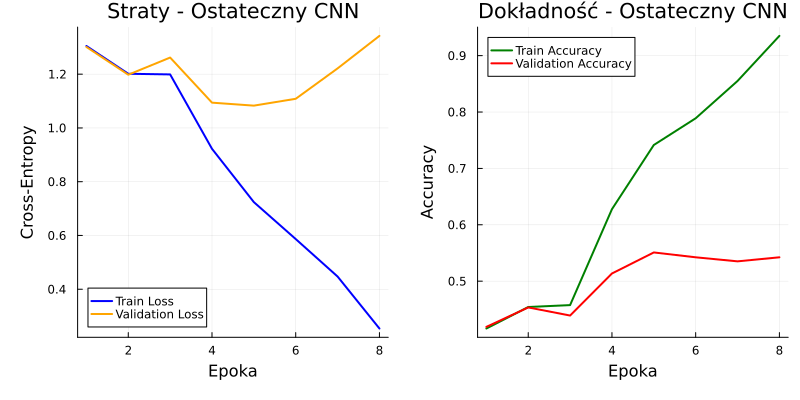

In [44]:
#Wykres f. straty i accuracy
actual_epochs_cnn = length(hist_t_loss_cnn_es)

p5 = plot(1:actual_epochs_cnn, hist_t_loss_cnn_es, label="Train Loss", lw=2, color=:blue, title="Straty - Ostateczny CNN")
plot!(p5, 1:actual_epochs_cnn, hist_v_loss_cnn_es, label="Validation Loss", lw=2, color=:orange)
xlabel!(p5, "Epoka")
ylabel!(p5, "Cross-Entropy")

p6 = plot(1:actual_epochs_cnn, hist_t_acc_cnn_es, label="Train Accuracy", lw=2, color=:green, title="Dokładność - Ostateczny CNN")
plot!(p6, 1:actual_epochs_cnn, hist_v_acc_cnn_es, label="Validation Accuracy", lw=2, color=:red)
xlabel!(p6, "Epoka")
ylabel!(p6, "Accuracy")

# Zwiększone marginesy zapobiegają ucięciu etykiet osi X i Y
display(plot(p5, p6, layout=(1, 2), size=(800, 400), bottom_margin=7Plots.Measures.mm, left_margin=7Plots.Measures.mm))


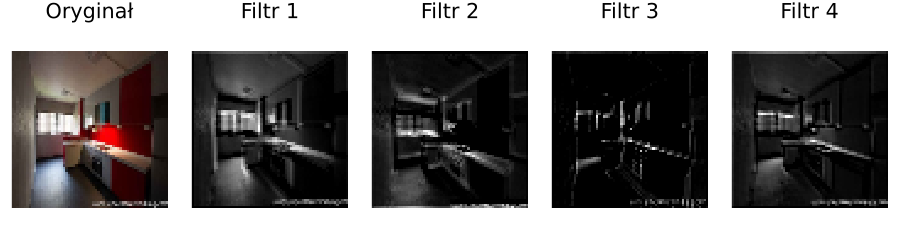

In [38]:

# Bierzemy całkowicie pierwszy obrazek ze zbioru testowego.
# X_test ma format (Szerokość, Wysokość, Kanały, Batch), pobieramy wycinek grubości 1 obrazu
sample_img_tensor = X_test[:, :, :, 1:1]

# Izolujemy pierwszą warstwę konwolucyjną. Nasz zwycięski model to Chain, a warstwa 1 to Conv.
first_conv_layer = best_es_model_cnn[1]

# Przepuszczamy nasz 1 obrazek wyłącznie przez tę jedną warstwę
feature_maps = first_conv_layer(sample_img_tensor)

# Pobieramy 4 przykładowe filtry (kanały wyjściowe) do wyświetlenia
num_filters_to_show = min(4, size(feature_maps, 3))
plots_array = []

# Dodajemy oryginalny obrazek dla porównania. Odtwarzamy go konwertując ułożenie wymiarów dla funkcji colorview z powrotem.
orig_img_for_plot = colorview(RGB, permutedims(X_test[:, :, :, 1], (3, 2, 1)))
push!(plots_array, plot(orig_img_for_plot, title="Oryginał", axis=false, ticks=false))

# Przetwarzamy każdy filtr jako obraz czarno-biały (jasne piksele = silna aktywacja krawędzi/cechy)
for i in 1:num_filters_to_show
    # Wyciągamy dwuwymiarową macierz i-tej mapy cech
    f_map = feature_maps[:, :, i, 1]' 
    
    # Skalujemy surowe liczby konwolucji do zakresu od 0.0 do 1.0 (potrzebne do wyświetlenia)
    f_map_norm = (f_map .- minimum(f_map)) ./ (maximum(f_map) .- minimum(f_map) .+ 1e-5)
    
    push!(plots_array, plot(colorview(Gray, f_map_norm), title="Filtr $i", axis=false, ticks=false))
end
# Wyświetlamy cały układ poziomo
display(plot(plots_array..., layout=(1, num_filters_to_show + 1), size=(900, 250)))



In [39]:

_, final_test_acc_cnn_es = evaluate_cnn(best_es_model_cnn, test_loader_cnn_final)
println("Ogólne Accuracy na Zbiorze Testowym: ", round(final_test_acc_cnn_es * 100, digits=2), "%\n")

Flux.testmode!(best_es_model_cnn, true) 
Y_test_pred_logits_cnn_es = best_es_model_cnn(X_test)
Y_test_pred_indices_cnn_es = onecold(Y_test_pred_logits_cnn_es)

# Definicja etykiet testowych po raz kolejny, dla bezpieczeństwa struktury komórek
Y_test_true_indices_cnn = onecold(Y_test)
Flux.testmode!(best_es_model_cnn, false)

C_cnn_es = zeros(Int, NUM_CLASSES, NUM_CLASSES)
for (p, t) in zip(Y_test_pred_indices_cnn_es, Y_test_true_indices_cnn)
    C_cnn_es[p, t] += 1
end

Ogólne Accuracy na Zbiorze Testowym: 53.95%



In [40]:
#Macierz pomylek
header_cnn_es = "PREDYKCJA \\ PRAWD. | " * join([rpad(string(cls), 10) for cls in unique_labels], " | ")
println(header_cnn_es)
println("-" ^ length(header_cnn_es))

for p in 1:NUM_CLASSES
    row_str = rpad(string(unique_labels[p]), 19) * "| "
    for t in 1:NUM_CLASSES
        row_str *= rpad(string(C_cnn_es[p, t]), 10) * " | "
    end
    println(row_str)
end


PREDYKCJA \ PRAWD. | bed        | din        | kitchen    | living    
----------------------------------------------------------------------
bed                | 109        | 22         | 23         | 35         | 
din                | 9          | 102        | 21         | 23         | 
kitchen            | 42         | 36         | 77         | 25         | 
living             | 27         | 39         | 19         | 88         | 


In [43]:
#Precision i recall per klasa
total_samples_cnn_es = sum(C_cnn_es)

for i in 1:NUM_CLASSES
    TP = C_cnn_es[i, i]
    total_predicted_as_i = sum(C_cnn_es[i, :])
    total_true_i = sum(C_cnn_es[:, i])
    TN = total_samples_cnn_es - total_predicted_as_i - total_true_i + TP
    
    precision = total_predicted_as_i > 0 ? TP / total_predicted_as_i : 0.0
    recall    = total_true_i > 0 ? TP / total_true_i : 0.0
        
    println("Klasa: ", rpad(uppercase(string(unique_labels[i])), 10), 
            "Precision: ", rpad(round(precision * 100, digits=2), 5), 
            "% | Recall: ", rpad(round(recall * 100, digits=2), 5), "%")
end

Klasa: BED       Precision: 57.67% | Recall: 58.29%
Klasa: DIN       Precision: 65.81% | Recall: 51.26%
Klasa: KITCHEN   Precision: 42.78% | Recall: 55.0 %
Klasa: LIVING    Precision: 50.87% | Recall: 51.46%


### Model 3 - CNN + Data Augmentation

Data augmentation: 50% szans na lustrzane odbicie, 50% szans na delikatne przesunięcie obrazu, 50% szans na modyfikacje jasności w granicach +-20%

In [ ]:
function augment_batch(x_batch)    
    x_aug = copy(x_batch) 
    
    for i in 1:size(x_aug, 4) 
        # 1. Losowe odbicie lustrzane w poziomie 
        if rand() > 0.5
            x_aug[:, :, :, i] = reverse(x_aug[:, :, :, i], dims=1)
        end
        
        # 2. Losowa zmiana jasności
        if rand() > 0.5
            factor = rand(0.8:0.05:1.2) # Mnożnik od 80% do 120% oryginalnej jasności            
            x_aug[:, :, :, i] = clamp.(x_aug[:, :, :, i] .* factor, 0.0f0, 1.0f0) 
        end
        
        # 3. Losowe delikatne przesunięcie o maksymalnie 4 piksele
        if rand() > 0.5
            shift_w = rand(-4:4)
            shift_h = rand(-4:4)
            x_aug[:, :, :, i] = circshift(x_aug[:, :, :, i], (shift_w, shift_h, 0))
        end
    end
    return x_aug
end

augment_batch (generic function with 1 method)

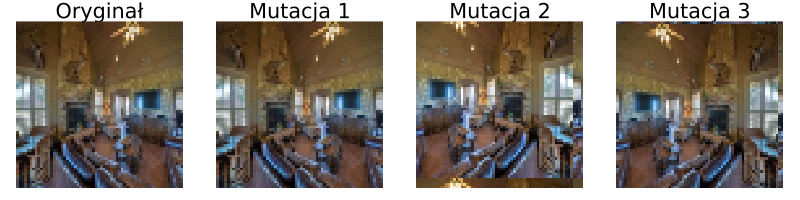

In [ ]:
# Wizualizacja dzialania data augmentation
demo_tensor = X_train[:, :, :, 1:1]
aug_plots = []
push!(aug_plots, plot(colorview(RGB, permutedims(demo_tensor[:,:,:,1], (3,2,1))), title="Oryginał", axis=false, ticks=false))

for i in 1:3
    mutated = augment_batch(demo_tensor)
    push!(aug_plots, plot(colorview(RGB, permutedims(mutated[:,:,:,1], (3,2,1))), title="Mutacja $i", axis=false, ticks=false))
end

display(plot(aug_plots..., layout=(1, 4), size=(800, 200)))

In [ ]:
#Trening z data augmentation na najlepszech architekturze z modelu 2
final_aug_topo = 2
final_aug_bs   = 32
final_aug_lr   = 0.001
final_aug_p    = 0.3

# Ze wzgledu na data augmentation tym razem 50 epok i patience = 7
max_epochs_aug = 50
patience_aug   = 7

aug_cnn_model = build_cnn_model(final_aug_topo, final_aug_p)
opt_state_aug = Flux.setup(Adam(final_aug_lr), aug_cnn_model)

train_loader_aug = DataLoader((X_train, Y_train), batchsize=final_aug_bs, shuffle=true)
val_loader_aug   = DataLoader((X_val, Y_val), batchsize=final_aug_bs, shuffle=false)
test_loader_aug  = DataLoader((X_test, Y_test), batchsize=final_aug_bs, shuffle=false)

hist_t_loss_aug, hist_v_loss_aug = Float64[], Float64[]
hist_t_acc_aug, hist_v_acc_aug   = Float64[], Float64[]

global best_val_acc_aug = 0.0
global patience_counter_aug = 0
global best_aug_model = nothing


@time for ep in 1:max_epochs_aug
    
    
    for (x, y) in train_loader_aug        
        x_mutated = augment_batch(x)
                
        Flux.train!(aug_cnn_model, [(x_mutated, y)], opt_state_aug) do m, x_in, y_in
            logitcrossentropy(m(x_in), y_in)
        end
    end
    
    # Ewaluacja 
    t_loss, t_acc = evaluate_cnn(aug_cnn_model, train_loader_aug)
    v_loss, v_acc = evaluate_cnn(aug_cnn_model, val_loader_aug)
    
    push!(hist_t_loss_aug, t_loss)
    push!(hist_v_loss_aug, v_loss)
    push!(hist_t_acc_aug, t_acc)
    push!(hist_v_acc_aug, v_acc)
    
    print("Epoka ", rpad(ep, 2), " (Augmentacja): Train Acc: ", rpad(round(t_acc*100, digits=2), 5), "% | ")
    print("Val Acc: ", rpad(round(v_acc*100, digits=2), 5), "%")
    
    # Early Stopping
    if v_acc > best_val_acc_aug
        global best_val_acc_aug = v_acc
        global patience_counter_aug = 0
        global best_aug_model = deepcopy(aug_cnn_model)
        println("  -> Nowy rekord! Zapisano model.")
    else
        global patience_counter_aug += 1
        println("  -> Brak poprawy (Od: $patience_counter_aug epok).")
    end
    flush(stdout)
    
    if patience_counter_aug >= patience_aug
        println("\n[EARLY STOPPING] Przerwano trening z augmentacją po $ep epokach.")
        break
    end
end

Epoka 1  (Augmentacja): Train Acc: 37.23% | Val Acc: 35.44%  -> Nowy rekord! Zapisano model.
Epoka 2  (Augmentacja): Train Acc: 43.11% | Val Acc: 42.18%  -> Nowy rekord! Zapisano model.
Epoka 3  (Augmentacja): Train Acc: 42.55% | Val Acc: 42.04%  -> Brak poprawy (Od: 1 epok).
Epoka 4  (Augmentacja): Train Acc: 50.83% | Val Acc: 48.92%  -> Nowy rekord! Zapisano model.
Epoka 5  (Augmentacja): Train Acc: 51.69% | Val Acc: 51.08%  -> Nowy rekord! Zapisano model.
Epoka 6  (Augmentacja): Train Acc: 57.51% | Val Acc: 55.95%  -> Nowy rekord! Zapisano model.
Epoka 7  (Augmentacja): Train Acc: 59.51% | Val Acc: 54.09%  -> Brak poprawy (Od: 1 epok).
Epoka 8  (Augmentacja): Train Acc: 59.66% | Val Acc: 56.38%  -> Nowy rekord! Zapisano model.
Epoka 9  (Augmentacja): Train Acc: 64.92% | Val Acc: 59.25%  -> Nowy rekord! Zapisano model.
Epoka 10 (Augmentacja): Train Acc: 64.18% | Val Acc: 58.54%  -> Brak poprawy (Od: 1 epok).
Epoka 11 (Augmentacja): Train Acc: 68.62% | Val Acc: 59.68%  -> Nowy rekord!

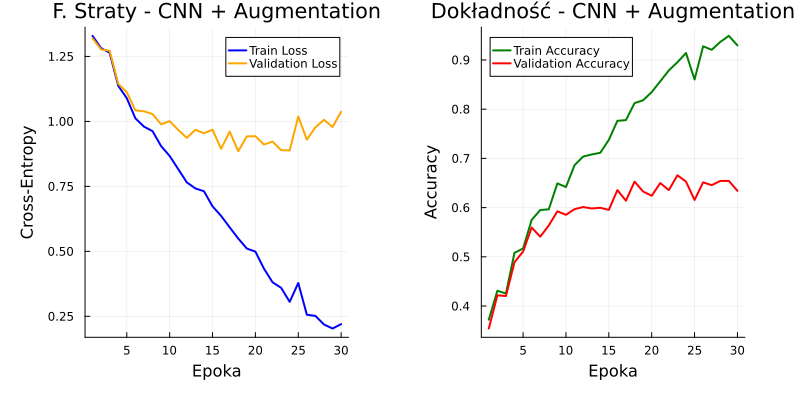

In [57]:
actual_epochs_aug = length(hist_t_loss_aug)

p7 = plot(1:actual_epochs_aug, hist_t_loss_aug, label="Train Loss", lw=2, color=:blue, title="F. Straty - CNN + Augmentation")
plot!(p7, 1:actual_epochs_aug, hist_v_loss_aug, label="Validation Loss", lw=2, color=:orange)
xlabel!(p7, "Epoka")
ylabel!(p7, "Cross-Entropy")

p8 = plot(1:actual_epochs_aug, hist_t_acc_aug, label="Train Accuracy", lw=2, color=:green, title="Dokładność - CNN + Augmentation")
plot!(p8, 1:actual_epochs_aug, hist_v_acc_aug, label="Validation Accuracy", lw=2, color=:red)
xlabel!(p8, "Epoka")
ylabel!(p8, "Accuracy")

display(plot(p7, p8, layout=(1, 2), size=(800, 400), bottom_margin=7Plots.Measures.mm, left_margin=7Plots.Measures.mm, right_margin=12Plots.Measures.mm ))


Ewaluacja modelu 3 na zbiorze testowym

In [ ]:
_, final_test_acc_aug = evaluate_cnn(best_aug_model, test_loader_aug)
println("Ogólne Accuracy na Zbiorze Testowym: ", round(final_test_acc_aug * 100, digits=2), "%\n")

Flux.testmode!(best_aug_model, true) 
Y_test_pred_logits_aug = best_aug_model(X_test)
Y_test_pred_indices_aug = onecold(Y_test_pred_logits_aug)

Y_test_true_indices_aug = onecold(Y_test)
Flux.testmode!(best_aug_model, false)

C_aug = zeros(Int, NUM_CLASSES, NUM_CLASSES)
for (p, t) in zip(Y_test_pred_indices_aug, Y_test_true_indices_aug)
    C_aug[p, t] += 1
end

Ogólne Accuracy na Zbiorze Testowym: 63.56%



In [51]:
#Macierz pomyłek
header_aug = "PREDYKCJA \\ PRAWD. | " * join([rpad(string(cls), 10) for cls in unique_labels], " | ")
println(header_aug)
println("-" ^ length(header_aug))

for p in 1:NUM_CLASSES
    row_str = rpad(string(unique_labels[p]), 19) * "| "
    for t in 1:NUM_CLASSES
        row_str *= rpad(string(C_aug[p, t]), 10) * " | "
    end
    println(row_str)
end

PREDYKCJA \ PRAWD. | bed        | din        | kitchen    | living    
----------------------------------------------------------------------
bed                | 122        | 10         | 19         | 23         | 
din                | 12         | 135        | 27         | 27         | 
kitchen            | 26         | 19         | 84         | 19         | 
living             | 27         | 35         | 10         | 102        | 


In [53]:
# Precision/recall per klasa
total_samples_aug = sum(C_aug)

for i in 1:NUM_CLASSES
    TP = C_aug[i, i]
    total_predicted_as_i = sum(C_aug[i, :])
    total_true_i = sum(C_aug[:, i])
    TN = total_samples_aug - total_predicted_as_i - total_true_i + TP
    
    precision = total_predicted_as_i > 0 ? TP / total_predicted_as_i : 0.0
    recall    = total_true_i > 0 ? TP / total_true_i : 0.0
        
    println("Klasa: ", rpad(uppercase(string(unique_labels[i])), 10), 
            "Precision: ", rpad(round(precision * 100, digits=2), 5), 
            "% | Recall: ", rpad(round(recall * 100, digits=2), 5), "%")
end

Klasa: BED       Precision: 70.11% | Recall: 65.24%
Klasa: DIN       Precision: 67.16% | Recall: 67.84%
Klasa: KITCHEN   Precision: 56.76% | Recall: 60.0 %
Klasa: LIVING    Precision: 58.62% | Recall: 59.65%
